### Задание 3
Загрузите данные по нашему кейсу с такси из файла uplift_data_less3.csv и сохраните их в переменную uplift_data. Затем сгруппируйте данные по признаку treatment и посчитайте средние значения для признаков target и uplift — для нас это и будет сравнением конверсий.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# загружаем данные с предсказанными значениями uplift
# index_col=0: первая колонка — идентификатор клиента, не признак
uplift_data = pd.read_csv('uplift_data_less3.csv', index_col=0)

# группируем данные по признаку treatment (0 - контрольная группа, 1 - тестовая группа)
# вычисляем средние значения целевой переменной (конверсии) и предсказанного uplift
conv = (uplift_data
    .groupby('treatment')
    # считаем средние значения target и uplift
    .agg({
        'target': 'mean',  # средняя конверсия в группе
        'uplift': 'mean'   # средний предсказанный uplift в группе
    })
    .reset_index()  # преобразуем индекс обратно в колонку для удобства просмотра
)

print(conv)

   treatment    target    uplift
0          0  0.195544  0.100059
1          1  0.293517  0.101229


### Задание 4
Запустите код ниже, чтобы с помощью библиотеки sklift построить Qini-кривую.

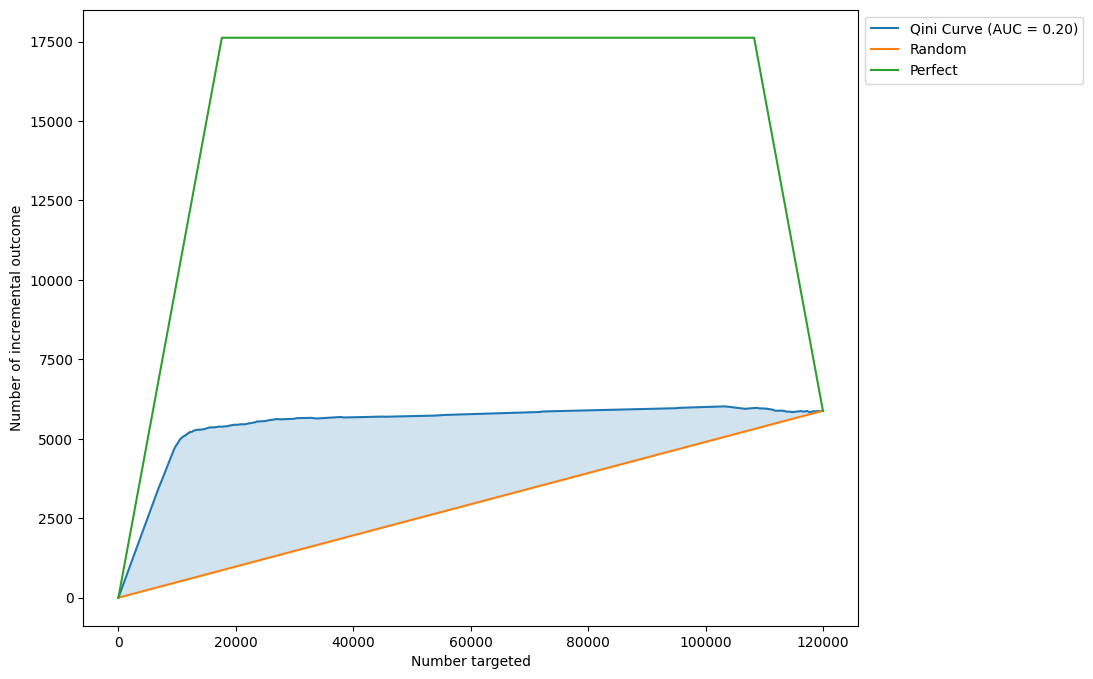

In [4]:
from sklift.viz import plot_qini_curve
import pandas as pd

# загружаем данные
uplift_data = pd.read_csv("uplift_data_less3.csv")

# извлекаем необходимые данные из датафрейма
target = uplift_data.target      # целевая переменная (фактический результат)
uplift = uplift_data.uplift      # предсказанные значения uplift
treatment = uplift_data.treatment # индикатор группы (1 - тестовая, 0 - контрольная)

fig, axs = plt.subplots(1, 1, figsize=(10, 8))
# строим Qini-кривую
# perfect=True добавляет идеальную кривую для сравнения
plot_qini_curve(target, uplift, treatment, perfect=True, ax=axs,
                  name='Qini Curve')


### Задание 5
Запустите код ниже, чтобы с помощью библиотеки sklift построить uplift-кривую.

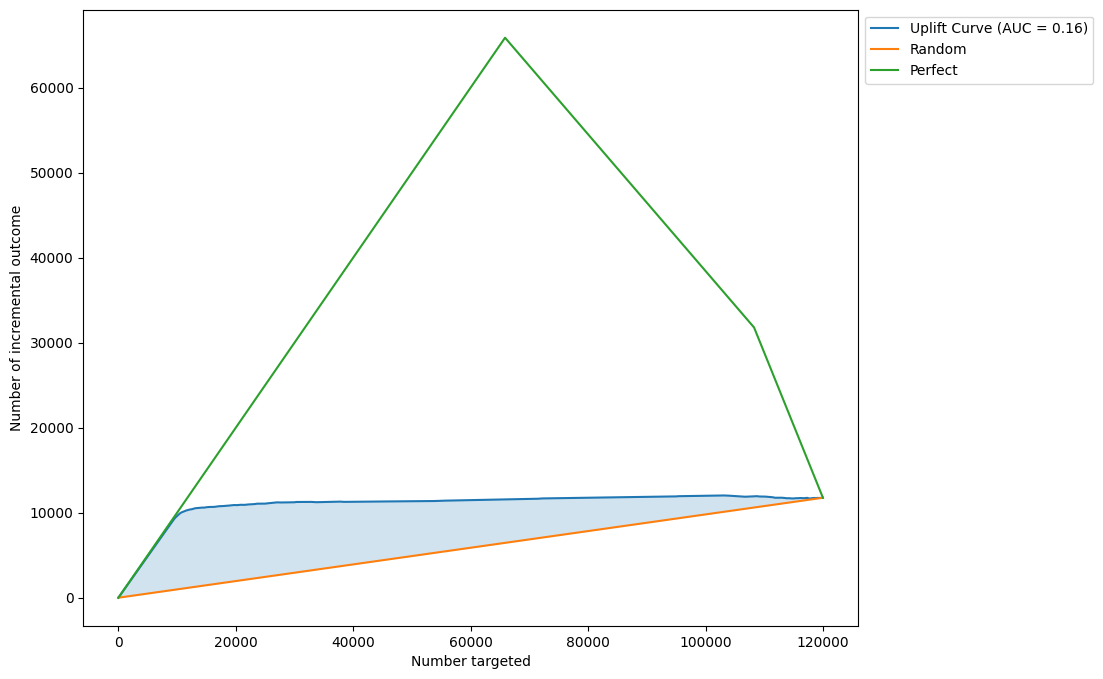

In [5]:
### код который уже использовали ранее
from sklift.viz import plot_uplift_curve
import pandas as pd

uplift_data = pd.read_csv("uplift_data_less3.csv")
# извлекаем необходимые данные из датафрейма
target = uplift_data.target      # целевая переменная (фактический результат)
uplift = uplift_data.uplift      # предсказанные значения uplift
treatment = uplift_data.treatment # индикатор группы (1 - тестовая, 0 - контрольная)
### конец ранее использованного кода

fig, axs = plt.subplots(1, 1, figsize=(10, 8))

# строим uplift-кривую
# perfect=True добавляет идеальную кривую для сравнения
plot_uplift_curve(target, uplift, treatment, perfect=True, ax=axs,
                  name='Uplift Curve')


### Задание 7
Рассчитаем uplift@k для нашего такси-датасета. Код, что вы напишете ниже, будет показывать топ-5% клиентов по значению uplift. Необходимо отсортировать всех клиентов по uplift-скору (это уже есть в прекоде), а затем из отсортированных значений выбрать топ-5% по значению uplift (вывести список топ-5% пользователей).

In [6]:
import pandas as pd

uplift_data = pd.read_csv("uplift_data_less3.csv")

# берём топ-5% клиентов по значению uplift
top_percent = 0.05

top_5_percent = (uplift_data
                .sort_values(by='uplift', ascending=False)
                # отбираем первые 5% строк: наибольший предсказанный uplift
                .head(int(len(uplift_data) * top_percent))
)

print(top_5_percent) 

        Unnamed: 0  treatment  target  uplift
119999      360820          0       0    1.00
95055       136785          1       1    1.00
9945        231112          0       0    1.00
114542       32825          1       1    1.00
60036       123719          1       1    1.00
...            ...        ...     ...     ...
53119       325736          0       0    0.97
53112       362935          1       1    0.97
14543       250759          1       1    0.97
74553       347891          0       0    0.97
34704       278589          0       0    0.97

[6000 rows x 4 columns]


### Uplift по перцентилям
Uplift по перцентилям — это метрика, которая позволяет оценить эффективность модели на различных сегментах данных, разделённых по перцентилям предсказанного uplift. Она даёт более детальное представление о том, как модель работает на разных группах пользователей, когда бизнесу ещё непонятно конкретное значение порога.
Процесс расчёта uplift по перцентилям:
- ранжируем все объекты по предсказанному значению uplift в порядке убывания;
- разделяем отсортированные объекты на n равных групп (например, децили — 10 групп по 10% объектов);
- для каждой группы вычисляем фактический uplift

In [9]:
from sklift.metrics import uplift_by_percentile  # расчёт uplift по перцентильным корзинам

def custom_uplift_by_percentile(y_true, uplift, treatment, 
                               kind='line', bins=10, string_percentiles=True, 
                               figsize=(10, 6), title=None):
    """
    Построение графика uplift по перцентилям.
    
    Аргументы:
        y_true: Бинарные целевые значения
        uplift: Прогнозируемые значения uplift
        treatment: Бинарные индикаторы воздействия
        kind: 'line' или 'bar'
        bins: Количество перцентильных корзин
        string_percentiles: Отображать ли перцентили в виде строк
        figsize: Размер рисунка (кортеж)
        title: Пользовательский заголовок для графика
    
    Возвращает:
        Рисунок matplotlib
    """
    
    # получаем данные по перцентилям, используя функцию из sklift
    df = uplift_by_percentile(
        y_true, uplift, treatment, strategy='overall',
        std=True, total=False, bins=bins, string_percentiles=False
    )
    
    # извлекаем перцентили из индекса DataFrame
    percentiles = df.index[:bins].values.astype(float)
    
    # извлекаем значения отклика для тестовой группы и их стандартные отклонения
    response_rate_trmnt = df.loc[percentiles, 'response_rate_treatment'].values
    std_trmnt = df.loc[percentiles, 'std_treatment'].values
    
    # извлекаем значения отклика для контрольной группы и их стандартные отклонения
    response_rate_ctrl = df.loc[percentiles, 'response_rate_control'].values
    std_ctrl = df.loc[percentiles, 'std_control'].values
    
    # извлекаем значения uplift и их стандартные отклонения
    uplift_score = df.loc[percentiles, 'uplift'].values
    std_uplift = df.loc[percentiles, 'std_uplift'].values
    
    # создаём график
    fig, ax = plt.subplots(figsize=figsize)
    
    if kind == 'line':
        # строим линейный график для тестовой группы с погрешностями
        ax.errorbar(
            percentiles, response_rate_trmnt, yerr=std_trmnt,
            linewidth=2, color='forestgreen', label='Отклик тестовой группы'
        )
        # строим линейный график для контрольной группы с погрешностями
        ax.errorbar(
            percentiles, response_rate_ctrl, yerr=std_ctrl,
            linewidth=2, color='orange', label='Отклик контрольной группы'
        )
        # строим линейный график для uplift с погрешностями
        ax.errorbar(
            percentiles, uplift_score, yerr=std_uplift,
            linewidth=2, color='red', label='Uplift'
        )
        # заполняем область между линиями тестовой и контрольной групп
        ax.fill_between(percentiles, response_rate_trmnt,
                        response_rate_ctrl, alpha=0.1, color='red')
        
        # добавляем горизонтальную линию на уровне 0, если есть отрицательные значения uplift
        if np.amin(uplift_score) < 0:
            ax.axhline(y=0, color='black', linewidth=1)
            
    elif kind == 'bar':
        # вычисляем ширину столбцов для столбчатой диаграммы
        width = percentiles[1] - percentiles[0] if len(percentiles) > 1 else 5
        bar_width = width * 0.35
        
        # строим столбцы для тестовой, контрольной групп и для uplift
        ax.bar(percentiles - bar_width, response_rate_trmnt, bar_width, 
               color='forestgreen', label='Отклик тестовой группы')
        ax.bar(percentiles, response_rate_ctrl, bar_width, 
               color='orange', label='Отклик контрольной группы')
        ax.bar(percentiles + bar_width, uplift_score, bar_width, 
               color='red', label='Uplift')
    
    # устанавливаем метки по оси X
    if string_percentiles:
        # создаём строковые метки для перцентилей (диапазоны)
        percentiles_str = [f"0-{percentiles[0]:.0f}"] + \
                          [f"{percentiles[i]:.0f}-{percentiles[i + 1]:.0f}" 
                           for i in range(len(percentiles) - 1)]
        ax.set_xticks(percentiles)
        ax.set_xticklabels(percentiles_str, rotation=45)
    else:
        # используем числовые значения перцентилей
        ax.set_xticks(percentiles)
    
    # устанавливаем подписи осей и заголовок
    ax.set_xlabel('Перцентиль')
    ax.set_ylabel('Уровень отклика / Uplift')
    
    # устанавливаем заголовок, если он предоставлен
    if title:
        ax.set_title(title)
  
    # добавляем легенду и сетку для улучшения читаемости
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # оптимизируем расположение элементов на графике
    plt.tight_layout()
    return fig


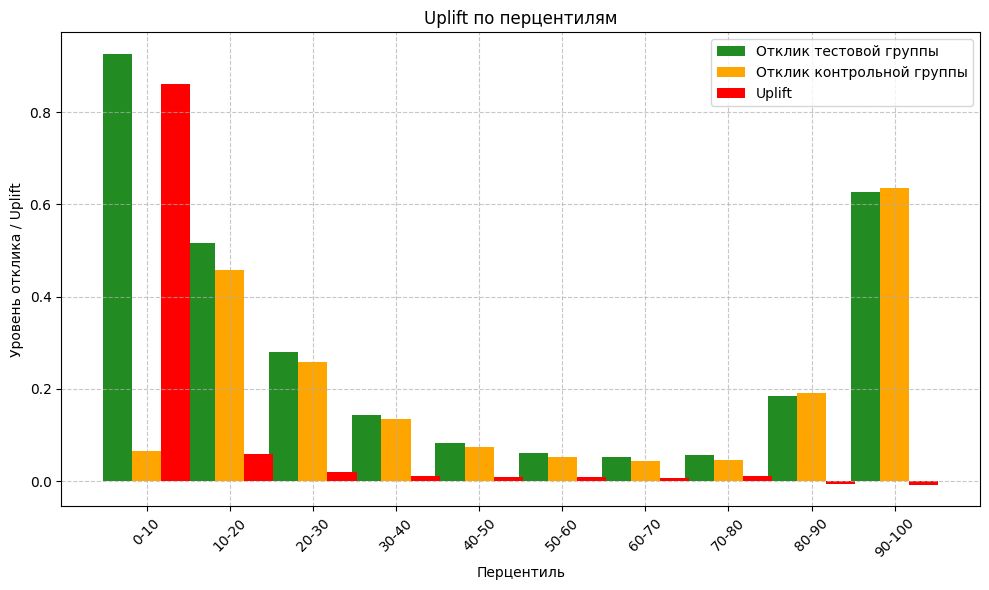

In [10]:
fig = custom_uplift_by_percentile(
    target,  # целевые значения
    uplift,  # прогнозируемые значения uplift
    treatment,  # индикаторы воздействия 
    kind='bar',  # тип графика — столбчатая диаграмма
    bins=10,  # количество перцентильных корзин
    title='Uplift по перцентилям'  # заголовок графика
)

### Задание 9
Постройте uplift-кривую на основе предсказаний модели, оценивающей эффект от предложения скидки на подписку Яндекс Плюс. Для этого используйте данные как по тестовой группе (клиенты, получившие предложение), так и по контрольной (клиенты без предложения).

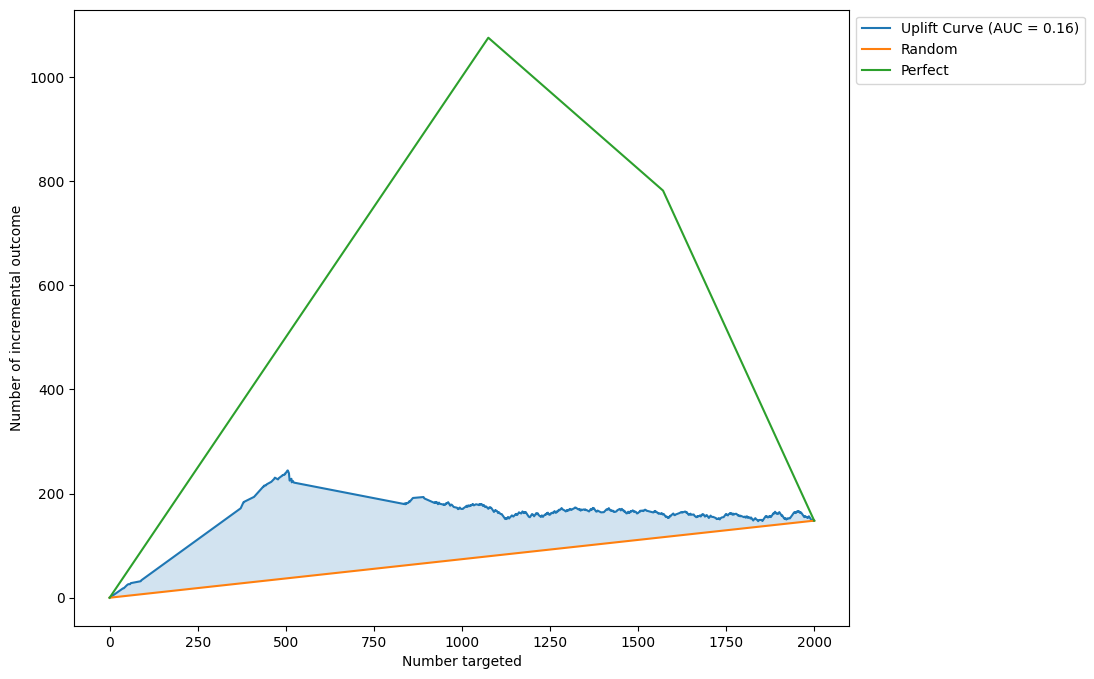

In [11]:
import pandas as pd
# импортируйте функцию для построения uplift-кривой
from sklift.viz import plot_uplift_curve  # график uplift-кривой из sklift

uplift_data = pd.read_csv("discount_uplift_metrics.csv")
conversion = uplift_data.conversion   # факт конверсии (подписка / покупка)
uplift = uplift_data.uplift_pred      # предсказанный эффект скидки на Яндекс Плюс
treatment = uplift_data.treatment     # 1 — получили предложение, 0 — контроль

fig, axs = plt.subplots(1, 1, figsize=(10, 8))
# вызовите функцию для построения кривой
# perfect=True добавляет идеальную кривую для сравнения
plot_uplift_curve(
    conversion, uplift, treatment,
    perfect=True,
    ax=axs,
    name='Uplift Curve'
)


### Задание 10
Постройте Qini-кривую. 

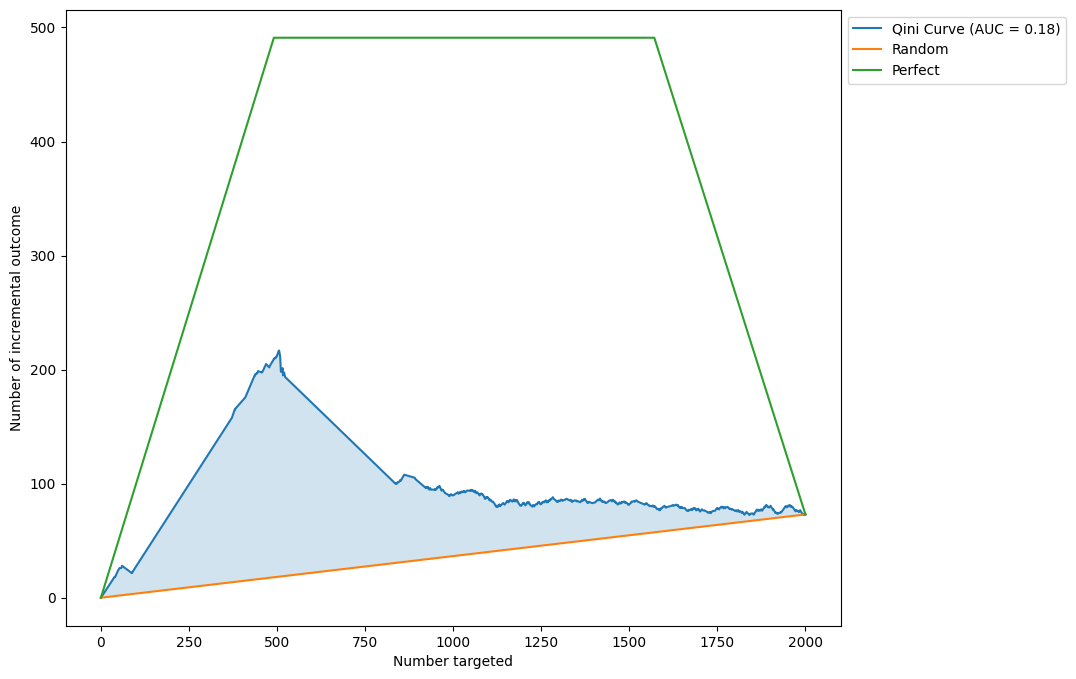

In [12]:
import pandas as pd
# импортируйте целевую функцию здесь

uplift_data = pd.read_csv("discount_uplift_metrics.csv")
conversion = uplift_data.conversion
uplift = uplift_data.uplift_pred
treatment = uplift_data.treatment

# ваш код здесь
from sklift.viz import plot_qini_curve  # функция построения Qini-кривой
fig, axs = plt.subplots(1, 1, figsize=(10, 8))
# perfect=True добавляет идеальную кривую для сравнения с моделью
plot_qini_curve(
    conversion, uplift, treatment,
    perfect=True,
    ax=axs,
    name='Qini Curve'
)


### Задание 11
Постройте график uplift по перцентилям на основе функции, представленной в уроке. Не забудьте использовать функцию из предыдущего задания.

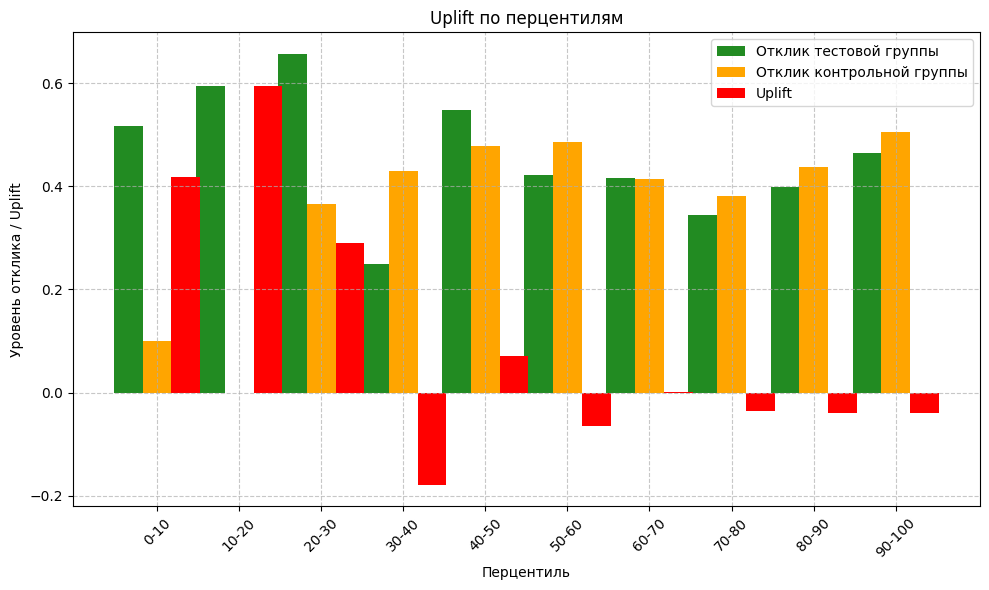

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklift.metrics import uplift_by_percentile

uplift_data = pd.read_csv("discount_uplift_metrics.csv")
conversion = uplift_data.conversion
uplift = uplift_data.uplift_pred
treatment = uplift_data.treatment

# ваш код здесь
# функция из урока: uplift по перцентилям на тех же conversion / uplift / treatment
fig = custom_uplift_by_percentile(
    conversion,  # факт конверсии
    uplift,      # предсказанный эффект скидки
    treatment,   # 1 — предложение скидки, 0 — контроль
    kind='bar',  # столбчатая диаграмма, как в примере урока
    bins=10,
    title='Uplift по перцентилям'
) 

 0.16 для uplift-кривой и 0.18 для Qini-кривой